In [6]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_uniswap_v2(T=1.0, dt=1/(365*24), mu=0.0, sigma=0.5, S0=1000.0, phi=0.003, initial_liquidity=10000):
    """
    Simule l'évolution d'une pool Uniswap V2 avec arbitrage via un prix CEX (MBG).
    """
    N = int(T / dt)
    t = np.linspace(0, T, N)
    
    # Génération du prix CEX (Mouvement Brownien Géométrique)
    W = np.random.standard_normal(size=N) 
    W = np.cumsum(W) * np.sqrt(dt)
    S_cex = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)
    
    # Initialisation de la pool
    # On suppose au départ que P_AMM = S0
    x = np.zeros(N)
    y = np.zeros(N)
    fee_x_cum = np.zeros(N)
    fee_y_cum = np.zeros(N)
    
    x[0] = initial_liquidity
    y[0] = initial_liquidity * S0
    k = x[0] * y[0]
    
    for i in range(1, N):
        S = S_cex[i]
        P_amm = y[i-1] / x[i-1]
        
        # Copie de l'état précédent
        x[i] = x[i-1]
        y[i] = y[i-1]
        fee_x_cum[i] = fee_x_cum[i-1]
        fee_y_cum[i] = fee_y_cum[i-1]
        k_current = x[i] * y[i]
        
        # Logique d'arbitrage
        if S > P_amm / (1 - phi):
            # CEX prix est plus haut -> Achat de X sur l'AMM avec du Y
            target_P = S * (1 - phi)
            # Nouvelles réserves théoriques pour atteindre le target_P
            x_target = np.sqrt(k_current / target_P)
            y_target = np.sqrt(k_current * target_P)
            
            delta_y = (y_target - y[i]) / (1 - phi) # Quantité de Y envoyée par le trader (inclut les frais)
            fee = delta_y * phi
            
            x[i] = x_target
            y[i] = y[i-1] + delta_y # Les frais restent dans la pool (k augmente légèrement)
            fee_y_cum[i] += fee
            
        elif S < P_amm * (1 - phi):
            # CEX prix est plus bas -> Vente de X à l'AMM contre du Y
            target_P = S / (1 - phi)
            x_target = np.sqrt(k_current / target_P)
            y_target = np.sqrt(k_current * target_P)
            
            delta_x = (x_target - x[i]) / (1 - phi) # Quantité de X envoyée
            fee = delta_x * phi
            
            x[i] = x[i-1] + delta_x
            y[i] = y_target
            fee_x_cum[i] += fee

    return t, S_cex, x, y, fee_x_cum, fee_y_cum

## Tâche 1 : Evolution temporelle

In [7]:
t, S_cex, x, y, fee_x, fee_y = simulate_uniswap_v2(T=30/365, dt=1/(365*24*6), phi=0.003) # Simulation sur 30 jours, points toutes les 10 mins

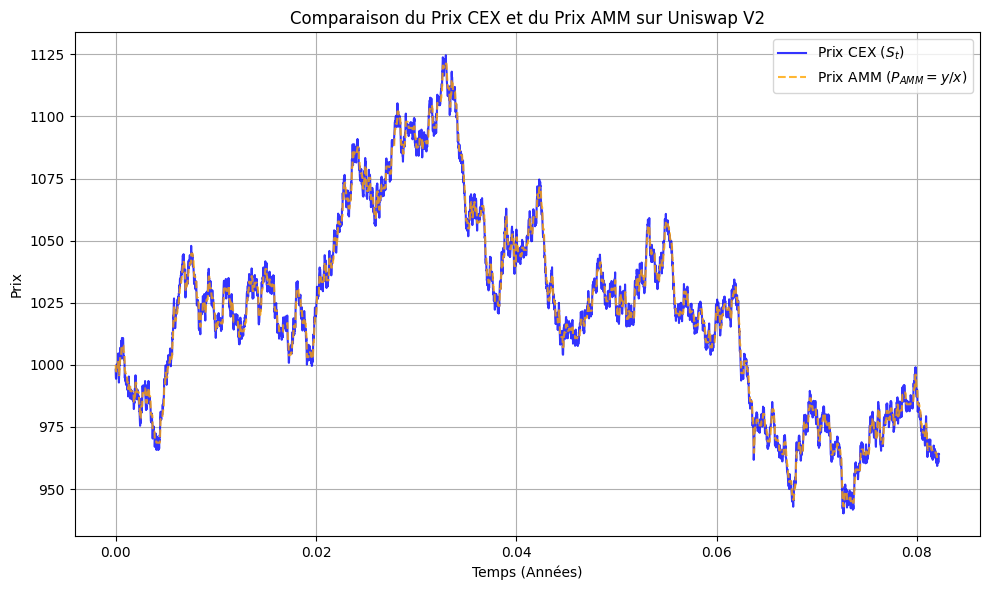

In [8]:
# Calcul du prix AMM (P = y / x)
P_amm = y / x

# Création du graphique de comparaison des prix
plt.figure(figsize=(10, 6))

# Tracé du prix CEX (ligne bleue continue)
plt.plot(t, S_cex, label='Prix CEX ($S_t$)', alpha=0.8, color='blue')

# Tracé du prix AMM (ligne orange en pointillés)
plt.plot(t, P_amm, label='Prix AMM ($P_{AMM} = y/x$)', alpha=0.8, color='orange', linestyle='--')

plt.title("Comparaison du Prix CEX et du Prix AMM sur Uniswap V2")
plt.xlabel("Temps (Années)")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

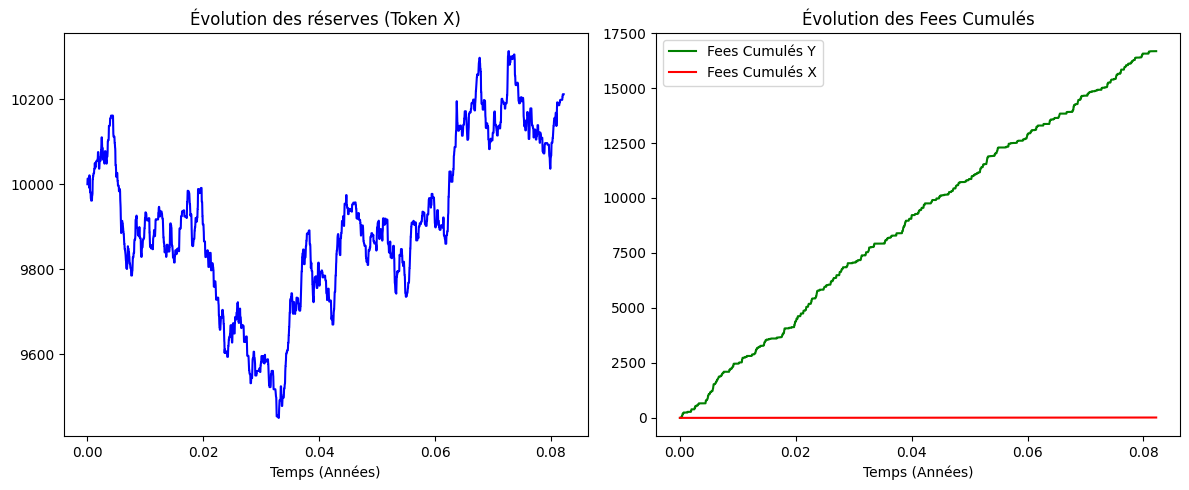

In [9]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t, x, label='Tokens X', color='blue')
plt.title("Évolution des réserves (Token X)")
plt.xlabel("Temps (Années)")

plt.subplot(1, 2, 2)
plt.plot(t, fee_y, label='Fees Cumulés Y', color='green')
plt.plot(t, fee_x, label='Fees Cumulés X', color='red')
plt.title("Évolution des Fees Cumulés")
plt.xlabel("Temps (Années)")
plt.legend()
plt.tight_layout()
plt.show()

<>:56: SyntaxWarning: invalid escape sequence '\P'
<>:56: SyntaxWarning: invalid escape sequence '\P'
C:\Users\abdel\AppData\Local\Temp\ipykernel_14956\1779356441.py:56: SyntaxWarning: invalid escape sequence '\P'
  plt.title("Zoom sur l'interaction Prix CEX / Prix AMM avec $\Phi = 2\%$")


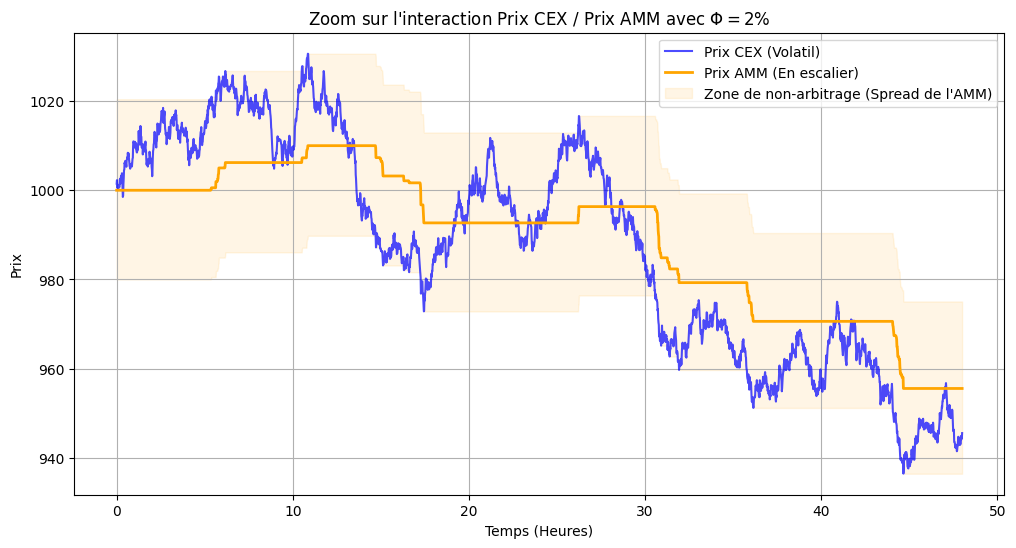

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_zoom_arbitrage(T=2/365, dt=1/(365*24*60), mu=0.0, sigma=0.8, S0=1000.0, phi=0.02, initial_liquidity=10000):
    # On simule sur 2 jours, point toutes les minutes, avec une grosse volatilité et 2% de frais
    N = int(T / dt)
    t = np.linspace(0, T, N)
    
    np.random.seed(10) # Seed choisie pour avoir de beaux zigzags
    W = np.random.standard_normal(size=N) 
    W = np.cumsum(W) * np.sqrt(dt)
    S_cex = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)
    
    x = np.zeros(N)
    y = np.zeros(N)
    x[0] = initial_liquidity
    y[0] = initial_liquidity * S0
    P_amm = np.zeros(N)
    P_amm[0] = S0
    
    for i in range(1, N):
        S = S_cex[i]
        P_amm_prev = y[i-1] / x[i-1]
        
        x[i] = x[i-1]
        y[i] = y[i-1]
        k_current = x[i] * y[i]
        
        # Si le CEX sort de la borne HAUTE
        if S > P_amm_prev / (1 - phi):
            target_P = S * (1 - phi)
            x[i] = np.sqrt(k_current / target_P)
            y[i] = np.sqrt(k_current * target_P) + ((np.sqrt(k_current * target_P) - y[i-1]) / (1 - phi)) * phi
            
        # Si le CEX sort de la borne BASSE
        elif S < P_amm_prev * (1 - phi):
            target_P = S / (1 - phi)
            x[i] = np.sqrt(k_current / target_P) + ((np.sqrt(k_current / target_P) - x[i-1]) / (1 - phi)) * phi
            y[i] = np.sqrt(k_current * target_P)
            
        P_amm[i] = y[i] / x[i]

    return t, S_cex, P_amm

t, S_cex, P_amm = simulate_zoom_arbitrage(phi=0.02) # Frais de 2% pour l'exemple visuel

# Bandes de non-arbitrage théoriques autour du prix AMM
borne_haute = P_amm / (1 - 0.02)
borne_basse = P_amm * (1 - 0.02)

plt.figure(figsize=(12, 6))
plt.plot(t * 365 * 24, S_cex, label='Prix CEX (Volatil)', color='blue', alpha=0.7)
plt.plot(t * 365 * 24, P_amm, label='Prix AMM (En escalier)', color='orange', linewidth=2)
plt.fill_between(t * 365 * 24, borne_basse, borne_haute, color='orange', alpha=0.1, label='Zone de non-arbitrage (Spread de l\'AMM)')

plt.title("Zoom sur l'interaction Prix CEX / Prix AMM avec $\Phi = 2\%$")
plt.xlabel("Temps (Heures)")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.show()

<>:95: SyntaxWarning: invalid escape sequence '\s'
<>:96: SyntaxWarning: invalid escape sequence '\P'
<>:97: SyntaxWarning: invalid escape sequence '\P'
<>:106: SyntaxWarning: invalid escape sequence '\P'
<>:95: SyntaxWarning: invalid escape sequence '\s'
<>:96: SyntaxWarning: invalid escape sequence '\P'
<>:97: SyntaxWarning: invalid escape sequence '\P'
<>:106: SyntaxWarning: invalid escape sequence '\P'
C:\Users\abdel\AppData\Local\Temp\ipykernel_14956\855298295.py:95: SyntaxWarning: invalid escape sequence '\s'
  ax1.axhline(theoretical_limit, color='red', linestyle='--', label='Limite Théorique Continue ($\sigma^2/8 \cdot V_0 \cdot T$)')
C:\Users\abdel\AppData\Local\Temp\ipykernel_14956\855298295.py:96: SyntaxWarning: invalid escape sequence '\P'
  ax1.set_title("Frais collectés en fonction de $\Phi$")
C:\Users\abdel\AppData\Local\Temp\ipykernel_14956\855298295.py:97: SyntaxWarning: invalid escape sequence '\P'
  ax1.set_xlabel("Taux de frais $\Phi$ (%)")
C:\Users\abdel\AppData\Lo

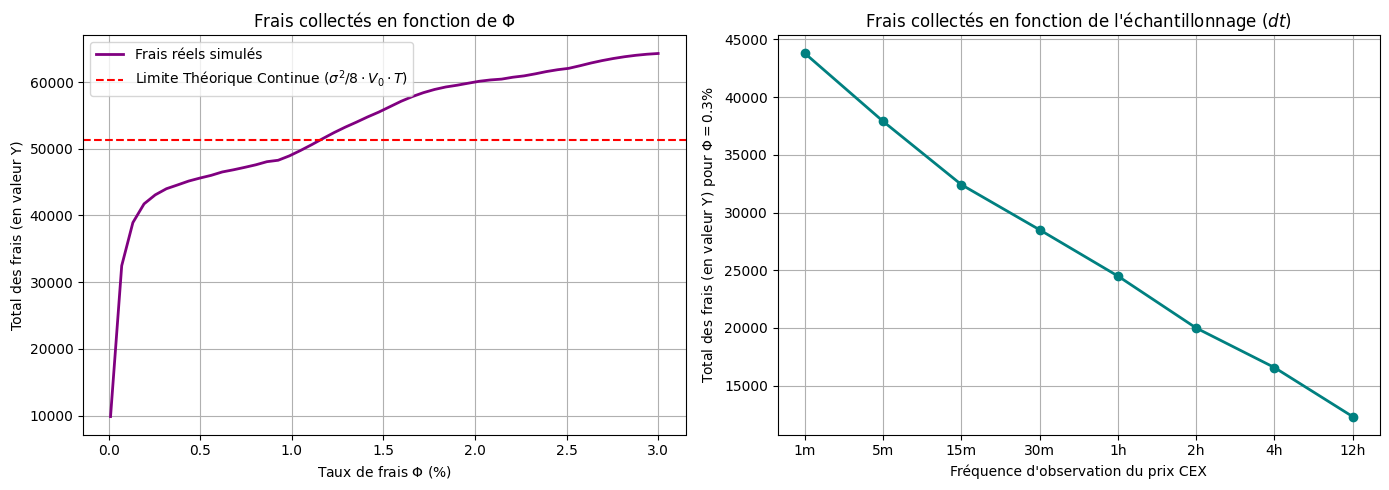

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Génération de la trajectoire de base
# ==========================================
T = 30 / 365                     # 30 jours
dt_base = 1 / (365 * 24 * 60)    # Haute fréquence : 1 minute
N_base = int(T / dt_base)
t_base = np.linspace(0, T, N_base)

mu, sigma, S0 = 0.0, 0.5, 1000.0
initial_liquidity = 10000

np.random.seed(42) # Seed fixe pour "toutes choses égales par ailleurs"
W = np.random.standard_normal(size=N_base)
W = np.cumsum(W) * np.sqrt(dt_base)
S_cex_base = S0 * np.exp((mu - 0.5 * sigma**2) * t_base + sigma * W)

# ==========================================
# 2. Fonction de calcul des fees sur une trajectoire
# ==========================================
def compute_total_fees(S_path, phi):
    """
    Simule l'AMM sur une trajectoire de prix donnée et retourne 
    la valeur totale des frais collectés (convertis en Token Y).
    """
    N = len(S_path)
    x, y = np.zeros(N), np.zeros(N)
    x[0] = initial_liquidity
    y[0] = initial_liquidity * S_path[0]
    
    fee_x_cum, fee_y_cum = 0.0, 0.0
    
    for i in range(1, N):
        S = S_path[i]
        x_prev, y_prev = x[i-1], y[i-1]
        P_amm = y_prev / x_prev
        k = x_prev * y_prev
        
        x[i], y[i] = x_prev, y_prev # État par défaut
        
        if S > P_amm / (1 - phi):
            target_P = S * (1 - phi)
            y_target = np.sqrt(k * target_P)
            delta_y = (y_target - y_prev) / (1 - phi)
            y[i] = y_prev + delta_y
            x[i] = np.sqrt(k / target_P)
            fee_y_cum += delta_y * phi
            
        elif S < P_amm * (1 - phi):
            target_P = S / (1 - phi)
            x_target = np.sqrt(k / target_P)
            delta_x = (x_target - x_prev) / (1 - phi)
            x[i] = x_prev + delta_x
            y[i] = np.sqrt(k * target_P)
            fee_x_cum += delta_x * phi
            
    # Valorisation finale de tous les frais en Token Y
    P_final = y[-1] / x[-1]
    total_fees_in_Y = fee_y_cum + fee_x_cum * P_final
    return total_fees_in_Y

# ==========================================
# 3. Analyse 1 : Fees en fonction de Phi
# ==========================================
phis = np.linspace(0.0001, 0.03, 50) # Phi de 0.01% à 3%
fees_vs_phi = [compute_total_fees(S_cex_base, phi) for phi in phis]

# Limite théorique (Uniswap V3 avec range infini = Uniswap V2)
# Formule continue d'Impernanent Loss / Fee capture : (sigma^2 / 8) * Valeur_Pool * T
V0 = 2 * initial_liquidity * S0 # Valeur totale initiale de la pool (en Y)
theoretical_limit = (sigma**2 / 8) * V0 * T

# ==========================================
# 4. Analyse 2 : Fees en fonction de l'échantillonnage (dt)
# ==========================================
# On sous-échantillonne la trajectoire de base (de 1 minute à 12 heures)
step_multipliers = [1, 5, 15, 30, 60, 120, 240, 720] # en minutes
dt_labels = ['1m', '5m', '15m', '30m', '1h', '2h', '4h', '12h']
fixed_phi = 0.003 # Frais classiques Uniswap (0.3%)

fees_vs_dt = []
for step in step_multipliers:
    S_subsampled = S_cex_base[::step] # On prend un point sur 'step'
    fees_vs_dt.append(compute_total_fees(S_subsampled, fixed_phi))

# ==========================================
# 5. Affichage des résultats
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 : Fees vs Phi
ax1.plot(phis * 100, fees_vs_phi, color='purple', linewidth=2, label='Frais réels simulés')
ax1.axhline(theoretical_limit, color='red', linestyle='--', label='Limite Théorique Continue ($\sigma^2/8 \cdot V_0 \cdot T$)')
ax1.set_title("Frais collectés en fonction de $\Phi$")
ax1.set_xlabel("Taux de frais $\Phi$ (%)")
ax1.set_ylabel("Total des frais (en valeur Y)")
ax1.grid(True)
ax1.legend()

# Plot 2 : Fees vs Échantillonnage
ax2.plot(dt_labels, fees_vs_dt, marker='o', color='teal', linewidth=2)
ax2.set_title("Frais collectés en fonction de l'échantillonnage ($dt$)")
ax2.set_xlabel("Fréquence d'observation du prix CEX")
ax2.set_ylabel("Total des frais (en valeur Y) pour $\Phi = 0.3\%$")
ax2.grid(True)

plt.tight_layout()
plt.show()